In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Utility: Overlay mask on image (grayscale or RGB)
def overlay_mask_rgb(img, mask, alpha=0.4, color=(1, 0, 0)):
    if len(img.shape) == 2:  # Grayscale
        img_rgb = np.stack([img] * 3, axis=-1) / 255.0
    elif len(img.shape) == 3 and img.shape[0] == 3:
        # Tensor image format: [C, H, W]
        img_rgb = img.transpose(1, 2, 0) / 255.0
    elif len(img.shape) == 3 and img.shape[-1] == 3:
        img_rgb = img / 255.0
    else:
        raise ValueError("Unsupported image shape:", img.shape)

    overlay = img_rgb.copy()
    overlay[mask == 1] = (1 - alpha) * overlay[mask == 1] + alpha * np.array(color)
    return overlay

In [15]:
# ------------------------------
# Change this to point to result
# ------------------------------
result_file = "shashank/shashank_models/OUTPUT_model_pruned_mp_[1024, 1024]_mlp_[512]_noAdjLearning_BS32_epoch_500_shashank/result_6.pt"  # Change index as needed


# Load the .pt file
result = torch.load(result_file)

img = result['image']
segments = result['segments']
gt_mask = result['gt_mask']
pred_mask = result['pred_mask']

# Convert to numpy (if not already)
if torch.is_tensor(img): img = img.numpy()
if torch.is_tensor(segments): segments = segments.numpy()
if torch.is_tensor(gt_mask): gt_mask = gt_mask.numpy()
if torch.is_tensor(pred_mask): pred_mask = pred_mask.numpy()

In [4]:
#result

In [4]:
for var in [gt_mask, pred_mask]:
    res, count = np.unique(var, return_counts=True)
    print(f"Unique values in {var} is: {res} and teh count is: {count}")


Unique values in [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] is: [  0   1   2   4   5   6   7   8   9  10  11  14  15  16  17  20  21  22
  26  27  29  32  39  40  42  43  45  52  54  61  63  68  71  72  74  75
  84  87  89  95 100 105 112 114 115 119 127 129 131 133 143 147 158 170
 171 176 178 181 185 186 189 191 196 200 201 202 204 207 209 216 222 223
 227 231 235 236 238 239 243 245 246 248 249 250 251 252 253 254 255] and teh count is: [49290     5     1     2     1    20     3     1     1     3     1     4
     1     1     4     1     1     1     1     1     1    21     1     1
     5     1     1     1     1     1     1     1     1     2     2     1
    14     1     1     1     1     1     4     1     1     1     1     2
     1     7    18     1     1     1     1     1    17     2     2     1
     2     3     1     1     4     1     1     2     1     1     1    20
     2     1     6     1     1     1     

In [5]:
img.shape, gt_mask.shape, pred_mask.shape

((224, 224), (224, 224), (224, 224))

In [ ]:
#np.unique(gt_mask)
# gt_mask = gt_mask != 0
# gt_mask = gt_mask.astype(np.uint8)
# print(np.unique(gt_mask))

[0 1]


In [12]:
#np.unique(segments, return_counts=True)
full_query_mask = segments != 0
full_query_mask = full_query_mask.astype(np.uint8)
print(np.unique(full_query_mask, return_counts=True))
#plt.imshow(segments, cmap="gray")

(array([0, 1], dtype=uint8), array([47747,  2429]))


In [8]:
result

{'image': array([[ 86,  86,  86, ...,  31, 119, 149],
        [ 86,  86,  86, ...,  31, 121, 147],
        [ 82,  82,  82, ...,  36, 124, 147],
        ...,
        [ 65,  62,  63, ..., 115, 113, 111],
        [ 65,  61,  62, ..., 117, 114, 113],
        [ 65,  61,  61, ..., 118, 117, 114]], dtype=uint8),
 'segments': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'gt_mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'pred_mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=

In [30]:
type(result['gt_query_part_superpixels']) #.cpu().numpy()

numpy.ndarray

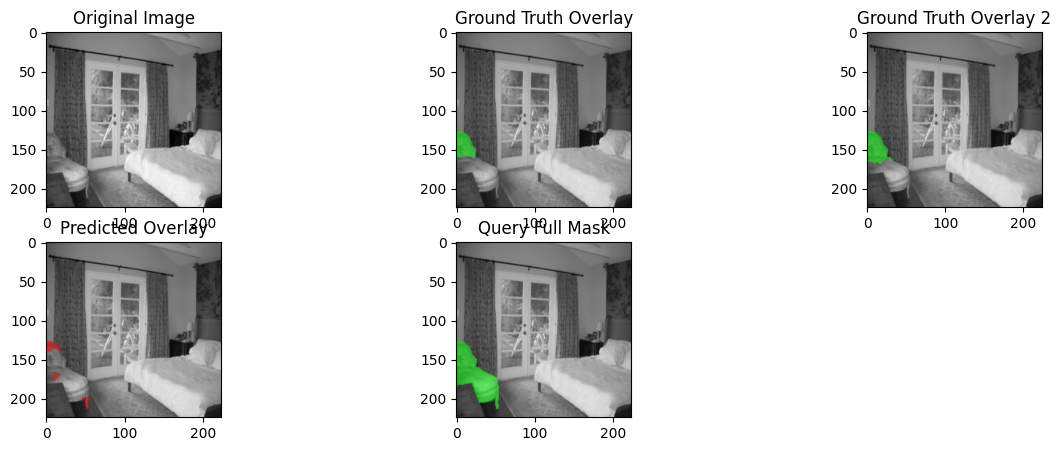

In [ ]:
# ------------------------------
# Show results
# ------------------------------
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(2, 3, 1)
plt.title("Original Image")
if img.ndim == 2:
    plt.imshow(img, cmap='gray')
else:
    plt.imshow(img.transpose(1, 2, 0).astype(np.uint8))  # [C,H,W] → [H,W,C]

# Ground Truth

gt_mask = gt_mask != 0
gt_mask = gt_mask.astype(np.uint8)

plt.subplot(2, 3, 2)
plt.title("Ground Truth Overlay")
overlay_gt = overlay_mask_rgb(img, gt_mask, alpha=0.5, color=(0, 1, 0))
plt.imshow(overlay_gt)

# superpixel pruned GT
gt_query_part_superpixels = result['gt_query_part_superpixels']
gt_mask2 = np.isin(segments, gt_query_part_superpixels).astype(np.uint8)

plt.subplot(2, 3, 3)
plt.title("Ground Truth Overlay 2")
overlay_gt = overlay_mask_rgb(img, gt_mask2, alpha=0.5, color=(0, 1, 0))
plt.imshow(overlay_gt)

# Prediction
plt.subplot(2, 3, 4)
plt.title("Predicted Overlay")
overlay_pred = overlay_mask_rgb(img, pred_mask, alpha=0.5, color=(1, 0, 0))
plt.imshow(overlay_pred)

# query full
plt.subplot(2, 3, 5)
plt.title("Query Full Mask")
full_mask = overlay_mask_rgb(img, full_query_mask, alpha=0.5, color=(0, 1, 0))
plt.imshow(full_mask)

In [ ]:
print(a)

In [ ]:
# Overlay helper
def overlay_mask_rgb(img, mask, alpha=0.5, color=(1, 0, 0)):
    """
    img: HxWx3 uint8
    mask: HxW binary
    color: tuple in [0,1] for RGB
    """
    imgf = img.astype(float) / 255.0
    c = np.array(color)[None,None,:]
    mask_bool = mask.astype(bool)
    imgf[mask_bool] = imgf[mask_bool] * (1-alpha) + c * alpha
    return (imgf * 255).astype(np.uint8)

In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime  # Import datetime
from model import Net

data_path = "shashank/shashank_data/test_processed_data_pruned_shashank"
output_dir = "shashank/shashank_predictions"
os.makedirs(output_dir, exist_ok=True)

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#MODEL_PATH = "/home/iiitb/Desktop/anant/GridRaster/saved_models/best_model.pth"
MODEL_PATH = "/home/iiitb/Desktop/anant/GridRaster/part_ours_training/shashank/shashank_models/model_pruned_mp_[1024, 1024]_mlp_[512]_noAdjLearning_BS32_epoch_500_shashank/best_model.pth"
MP_ACT = 'ELU'
MLP_ACT = 'ReLU'
IN_CHANNELS = 1024
NUM_CLUSTERS = 2
MP_UNITS = [1024, 1024] 
MLP_UNITS = [512]


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = Net(
    mp_units=MP_UNITS,
    mp_act=MP_ACT,
    in_channels=IN_CHANNELS,
    n_clusters=NUM_CLUSTERS,
    mlp_units=MLP_UNITS,
    mlp_act=MLP_ACT
).to(DEVICE)

#model = DenseMinCutNet(in_channels=1024, hidden_channels=64, out_clusters=2).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
print("Loaded model for inference.")


for i in range(5923):
    data_raw_path = os.path.join(data_path, f"graph_{i}.pt")
    data = torch.load(data_raw_path)
    data = data.to(DEVICE)

    with torch.no_grad():
        out, _, _ = model(data.x, data.edge_index, data.edge_weight, batch=torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE))

    predicted = out.argmax(dim=1).cpu().numpy()


    segments = data.segments.cpu().numpy()                      # 2D label map of superpixels
    query_full_superpixels = data.query_full_superpixels.cpu().numpy()  # list of superpixel IDs used

    # id_map: superpixel ID → prediction label
    id_map = {sp_id: predicted[i] for i, sp_id in enumerate(query_full_superpixels)}

    # Reconstruct predicted mask
    pred_mask = np.zeros_like(segments, dtype=np.uint8)
    for sp_id, label in id_map.items():
        pred_mask[segments == sp_id] = label


    gt_query_part_superpixels = data.gt_query_part_superpixels.cpu().numpy()
    # Ground Truth Part Mask
    gt_mask = np.isin(segments, gt_query_part_superpixels).astype(np.uint8)

    #print(f"query full superpixels number: {query_full_superpixels} and count {len(query_full_superpixels)} | query part superpixels number {gt_query_part_superpixels} and count {len(gt_query_part_superpixels)}")

    # Retrieve and prepare image
    img_t = data.image  # shape [H, W]
    img_np = img_t.cpu().numpy()

    # If single channel, convert to RGB
    if img_np.ndim == 2:
        img_gray = img_np
        img_rgb = np.stack([img_gray]*3, axis=-1)  # [H, W, 3]
    else:
        # If it's [C, H, W], permute to [H, W, C]
        img_rgb = img_np.transpose(1, 2, 0)
        # If normalized in [0,1], scale to [0,255]:
        if img_rgb.max() <= 1.0:
            img_rgb = (img_rgb * 255).astype(np.uint8)

    
    # Create overlays
    gt_overlay = overlay_mask_rgb(img_rgb, gt_mask, alpha=0.4, color=(0,1,0))
    pred_overlay = overlay_mask_rgb(img_rgb, pred_mask, alpha=0.4, color=(1,0,0))

    # Plot
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Origina Image")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title("Ground Part Truth Mask")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(gt_overlay)
    plt.title("GT Part Overlay (green)")
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(pred_overlay)
    plt.title("Predicted Part Overlay (red)")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    gt_full_mask = np.isin(segments, query_full_superpixels).astype(np.uint8)
    gt_full_overlay = overlay_mask_rgb(img_rgb, gt_full_mask, alpha=0.4, color=(0,1,0))
    plt.imshow(gt_full_overlay)
    plt.title("Predicted Full Overlay (red)")
    plt.axis('off')

    plt.tight_layout()

    # Create timestamp string
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save the figure with timestamp
    save_path = os.path.join(output_dir, f"ADE_objectID_{data.object_id}_partID_{data.part_id}_{timestamp}.png")
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close()


Loaded model for inference.


FileNotFoundError: [Errno 2] No such file or directory: 'shashank/shashank_data/test_processed_data_pruned_shashank/graph_0.pt'